# UNEMPLOYMENT ANALYSIS IN INDIA DURING
# THE PRE & POST COVID PERIOD

## Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on unemployment data in India. The analysis focuses on identifying regional and monthly trends, understanding the relationship between employment indicators, and studying the impact of the COVID-19 pandemic on unemployment rates.

In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import seaborn for attractive statistical visualizations
import seaborn as sns

# Set the plotting style
plt.style.use("ggplot")

# Increase the default font size
sns.set(font_scale=1.1)

In [2]:
# Load the CSV file into a DataFrame
df = pd.read_csv("Unemployment in India.csv")

# Display the first five rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Step 2: Inspect the Dataset

This section checks the size, structure, and summary statistics of the dataset.

In [3]:
# Display number of rows and columns
print("Dataset Shape:")
print(df.shape)

# Display complete information about the dataset
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Display column names
print("\nColumn Names:")
print(df.columns)

Dataset Shape:
(768, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB

Statistical Summary:
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean        

## Step 3: Data Cleaning

Clean the column names, rename important columns, and check for missing values.

In [4]:
# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

# Rename columns for easier access
df.rename(columns={
    "Region": "State",
    "Estimated Unemployment Rate (%)": "Unemployment",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "LabourParticipation"
}, inplace=True)

# Display updated column names
print(df.columns)

# Count missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove rows containing missing values
df.dropna(inplace=True)

# Verify missing values have been removed
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Index(['State', 'Date', 'Frequency', 'Unemployment', 'Employed',
       'LabourParticipation', 'Area'],
      dtype='object')

Missing Values:
State                  28
Date                   28
Frequency              28
Unemployment           28
Employed               28
LabourParticipation    28
Area                   28
dtype: int64

Missing Values After Cleaning:
State                  0
Date                   0
Frequency              0
Unemployment           0
Employed               0
LabourParticipation    0
Area                   0
dtype: int64


## Step 4: Convert Date Column

Convert the Date column into datetime format for time-series analysis.

In [5]:
# Convert Date column into datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Verify data types
print(df.dtypes)

# Display first five rows
df.head()

State                          object
Date                   datetime64[ns]
Frequency                      object
Unemployment                  float64
Employed                      float64
LabourParticipation           float64
Area                           object
dtype: object


C:\Users\Asus\AppData\Local\Temp\ipykernel_10856\3042795983.py:2: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


,State,Date,Frequency,Unemployment,Employed,LabourParticipation,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


## Step 5: Region-wise Average Unemployment Rate

Calculate the average unemployment rate for each state and visualize the results.

In [6]:
# Calculate average unemployment rate by state
average_unemployment = df.groupby("State")["Unemployment"].mean()

# Sort the values in descending order
average_unemployment = average_unemployment.sort_values(ascending=False)

# Display average unemployment rate
print(average_unemployment)

State
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Unemployment, dtype: float64


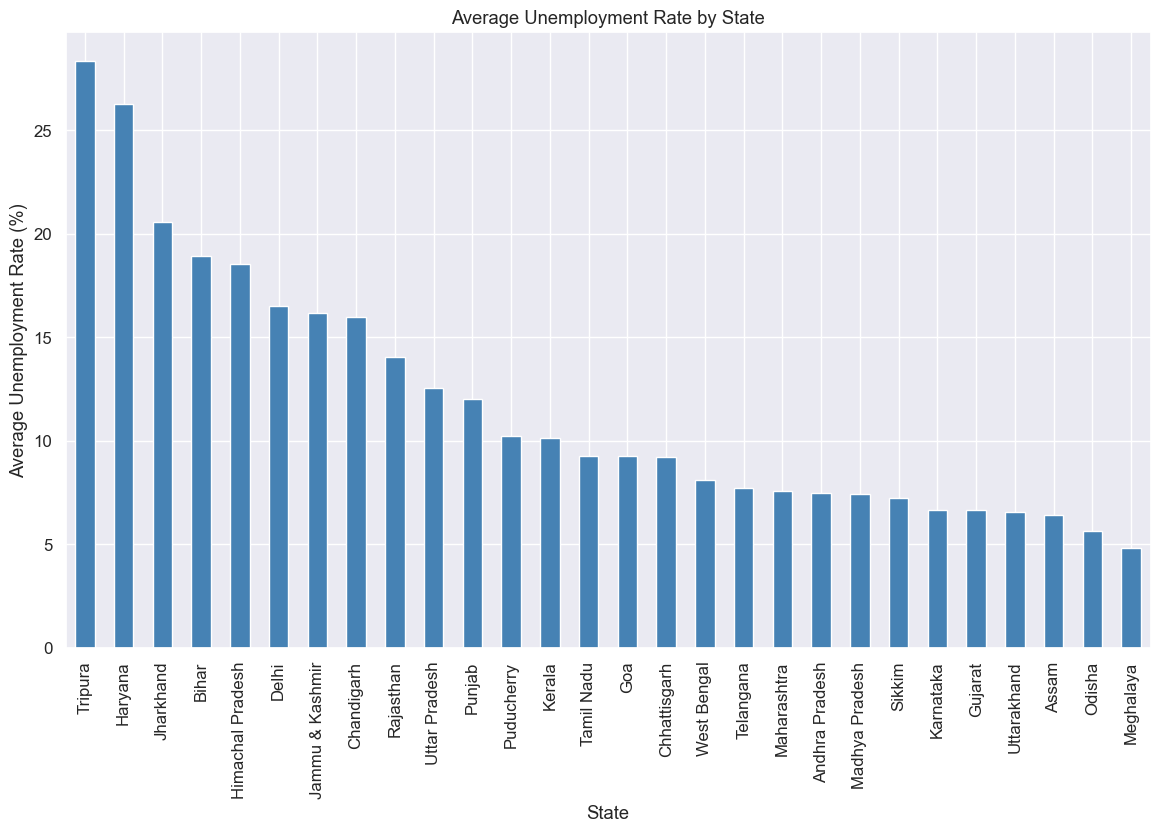

In [7]:
# Set figure size
plt.figure(figsize=(14,8))

# Create a bar chart
average_unemployment.plot(kind="bar", color="steelblue")

# Add chart title
plt.title("Average Unemployment Rate by State")

# Add x-axis label
plt.xlabel("State")

# Add y-axis label
plt.ylabel("Average Unemployment Rate (%)")

# Rotate x-axis labels
plt.xticks(rotation=90)

# Display the graph
plt.show()

### OBSERVATION-
The unemployment rate varies significantly across different states in India.
Tripura has the highest average unemployment rate, followed by Haryana.
States such as Jharkhand, Bihar, Himachal Pradesh, and Delhi also show relatively high unemployment rates.
Meghalaya has the lowest average unemployment rate, followed by Odisha and Assam.
Most states have unemployment rates below 10%, while only a few states have very high unemployment, indicating regional differences in employment opportunities.

## Step 6: Month-wise Unemployment Trend

This analysis shows how unemployment changes over different months.

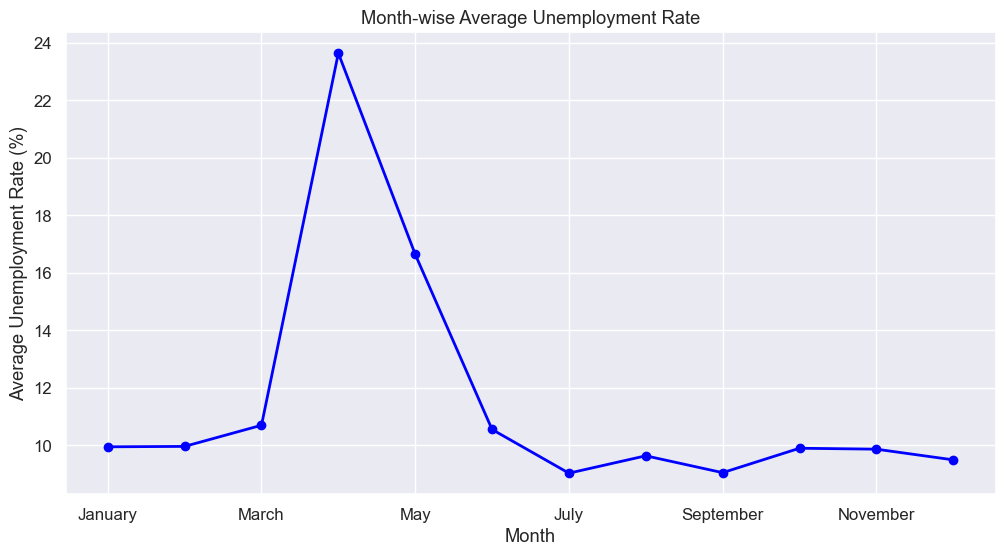

In [8]:
# Create a new column containing month names
df["Month"] = df["Date"].dt.month_name()

# Calculate average unemployment for each month
monthly = df.groupby("Month")["Unemployment"].mean()

# Arrange the months in calendar order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

# Reorder the monthly data
monthly = monthly.reindex(month_order)

# Set figure size
plt.figure(figsize=(12,6))

# Plot the monthly trend
monthly.plot(
    marker="o",
    linewidth=2,
    color="blue"
)

# Add chart title
plt.title("Month-wise Average Unemployment Rate")

# Add x-axis label
plt.xlabel("Month")

# Add y-axis label
plt.ylabel("Average Unemployment Rate (%)")

# Display grid
plt.grid(True)

# Display the graph
plt.show()

### Observation

The unemployment rate varies from month to month. A noticeable increase is generally observed during the COVID-19 lockdown period.

## Step 7: Time-Series Analysis of Major States

This section compares unemployment trends over time for four Indian states.

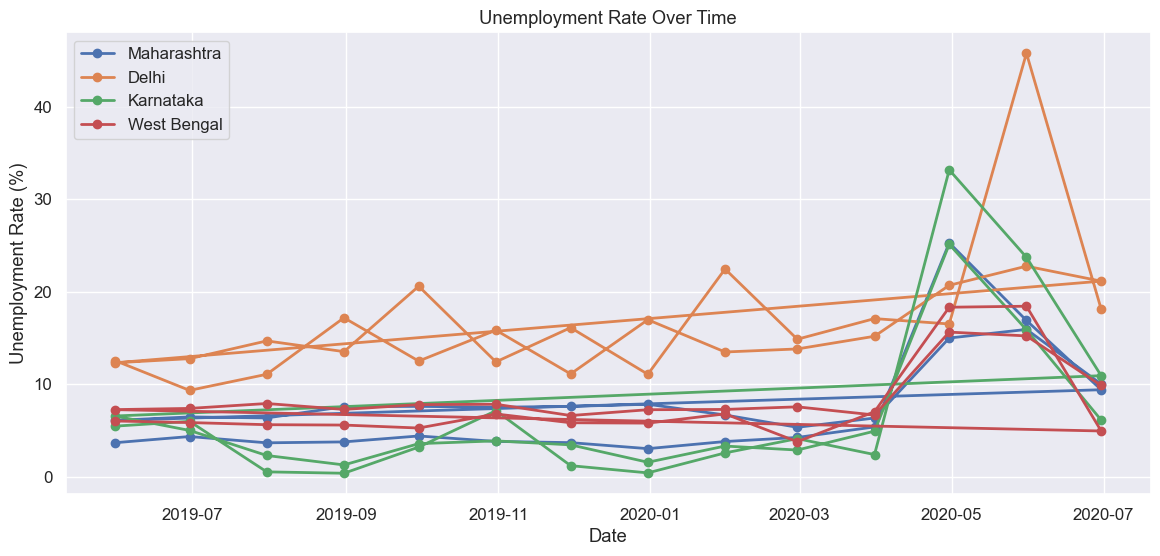

In [14]:
# Select three major states
states = ["Maharashtra", "Delhi", "Karnataka", "West Bengal"]

# Set figure size
plt.figure(figsize=(14,6))

# Loop through each selected state
for state in states:

    # Filter the dataset for the selected state
    temp = df[df["State"] == state]

    # Plot unemployment rate over time
    plt.plot(
        temp["Date"],
        temp["Unemployment"],
        marker="o",
        linewidth=2,
        label=state
    )

# Add chart title
plt.title("Unemployment Rate Over Time")

# Add x-axis label
plt.xlabel("Date")

# Add y-axis label
plt.ylabel("Unemployment Rate (%)")

# Display legend
plt.legend()

# Display grid
plt.grid(True)

# Show the graph
plt.show()

### Observation:
The unemployment rate changes over time for all four states.
Delhi records the highest unemployment rate, with a sharp peak around June 2020.
Karnataka also experiences a significant increase during the same period, but the rate decreases afterward.
Maharashtra shows moderate fluctuations and remains relatively more stable than Delhi and Karnataka.
West Bengal has the lowest and most stable unemployment rate throughout the observed period, with only a slight increase during mid-2020.
The rise in unemployment around May–June 2020 is due to the economic impact of the COVID-19 lockdown.

## Step 8: Correlation Heatmap

A heatmap helps us understand the relationship between unemployment, employment, and labour participation.

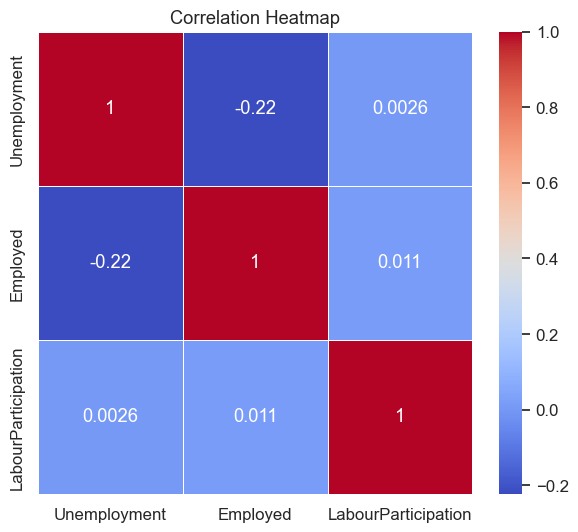

In [10]:
# Select numerical columns for correlation
corr = df[
    [
        "Unemployment",
        "Employed",
        "LabourParticipation"
    ]
].corr()

# Set figure size
plt.figure(figsize=(7,6))

# Draw the heatmap
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

# Add chart title
plt.title("Correlation Heatmap")

# Display the graph
plt.show()

### observation --
The heatmap shows the correlation between Unemployment, Employment, and Labour Participation.
Unemployment and Employment have a weak negative correlation (-0.22), indicating that as employment increases, unemployment tends to decrease slightly.
Unemployment and Labour Participation have almost no correlation (0.0026), showing almost no linear relationship.
Employment and Labour Participation also have a very weak positive correlation (0.011), indicating almost no relationship.
The diagonal values are 1.0 because each variable is perfectly correlated with itself.

## Step 9: Pre-COVID vs Post-COVID Comparison

Compare unemployment rates before and after the COVID-19 outbreak.

In [11]:
# Separate data before March 2020
pre_covid = df[df["Date"] < "2020-03-01"]

# Separate data from March 2020 onwards
post_covid = df[df["Date"] >= "2020-03-01"]

# Create a comparison DataFrame
comparison = pd.DataFrame({

    "Period": ["Pre-COVID", "Post-COVID"],

    "Average Unemployment": [

        pre_covid["Unemployment"].mean(),

        post_covid["Unemployment"].mean()

    ]
})

# Display comparison table
comparison

,Period,Average Unemployment
0,Pre-COVID,9.509534
1,Post-COVID,17.774363


C:\Users\Asus\AppData\Local\Temp\ipykernel_10856\948273242.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


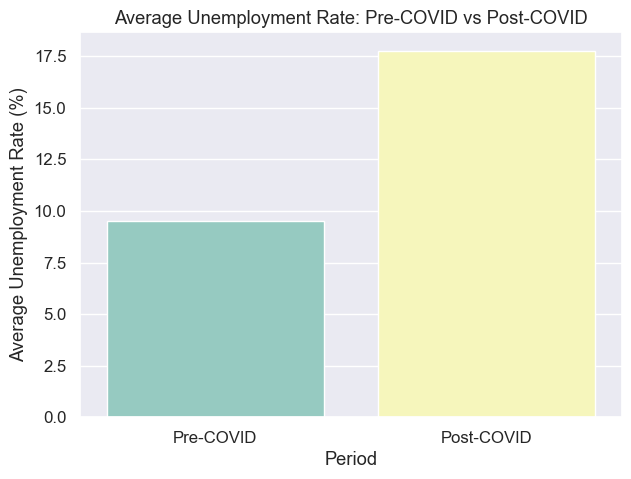

In [15]:
# Set figure size
plt.figure(figsize=(7,5))

# Draw the comparison chart
sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment",
    palette="Set3"
)

# Add chart title
plt.title("Average Unemployment Rate: Pre-COVID vs Post-COVID")

# Add y-axis label
plt.ylabel("Average Unemployment Rate (%)")

# Display the graph
plt.show()

### Observation

The average unemployment rate increased significantly after the COVID-19 outbreak, demonstrating the pandemic's impact on employment across India.

## Step 11: Final Insights

Summarize the major findings obtained from the analysis.

In [13]:
# Display the state with the highest average unemployment
print("State with Highest Average Unemployment Rate:")
print(average_unemployment.idxmax())

# Display the highest unemployment rate
print("\nHighest Average Unemployment Rate:")
print(round(average_unemployment.max(), 2), "%")

# Display overall average unemployment rate
print("\nOverall Average Unemployment Rate:")
print(round(df["Unemployment"].mean(), 2), "%")

# Display total number of states
print("\nNumber of States/Regions:")
print(df["State"].nunique())

# Display total records
print("\nTotal Records:")
print(df.shape[0])

State with Highest Average Unemployment Rate:
Tripura

Highest Average Unemployment Rate:
28.35 %

Overall Average Unemployment Rate:
11.79 %

Number of States/Regions:
28

Total Records:
740


### Conclusion

In this project, Exploratory Data Analysis (EDA) was performed on the unemployment dataset of India using Python. The dataset was cleaned, inspected, and analyzed to understand unemployment trends across different states and over time.

The analysis revealed that unemployment rates vary significantly among states, with some regions consistently showing higher average unemployment. Monthly trend analysis indicated noticeable fluctuations in unemployment rates, especially during the COVID-19 pandemic. The time-series analysis of major states showed a sharp rise in unemployment during the lockdown period, followed by a gradual recovery in subsequent months.

The correlation heatmap helped identify the relationships between unemployment rate, employment, and labour participation rate, providing deeper insights into the labour market. Furthermore, the comparison between the pre-COVID and post-COVID periods confirmed that the pandemic had a substantial impact on unemployment across the country.

Overall, this project demonstrates how Python libraries such as Pandas, Matplotlib, and Seaborn can be effectively used for data cleaning, visualization, and analysis. The insights obtained from this analysis can help researchers, policymakers, and economists better understand unemployment patterns and support informed decision-making.